# Change-point detection and segmentation

How to find the moments a time series changes regime - a shift in mean, variance, or rate - two complementary ways: a model-based approach (a hidden Markov model whose states are the regimes, decoded by Viterbi) and a direct offline search (dynamic programming for the optimal segmentation under a penalty). Both turn "where did things change?" into a likelihood question.


## Offline change-point detection as optimal partitioning

Given a series $y_1,\dots,y_T$, partition it into contiguous segments so that each segment is
homogeneous. With a segment cost $\mathcal C(i,j)$ (for a piecewise-constant mean, the within-segment sum
of squared errors) and a per-segment penalty $\beta$, the offline problem is
$$\min_{\text{partitions}} \sum_{\text{segments }(i,j)} \big[\mathcal C(i,j) + \beta\big].$$

Theorem (the dynamic program is globally optimal). Let $F(t)$ be the optimal cost of segmenting $y_{1:t}$.
Then $F(0)=-\beta$ and
$$F(t) = \min_{0\le s<t}\ \big[F(s) + \mathcal C(s{+}1,t) + \beta\big].$$
Backtracking the minimizing $s$ recovers the globally optimal partition in $O(T^2)$ time (with prefix
sums, each cost is $O(1)$).

Proof. The cost is additive over segments, and the optimal segmentation of $y_{1:t}$ ending in a segment
that starts at $s+1$ must use the optimal segmentation of $y_{1:s}$ for the prefix (otherwise replacing
the prefix would lower the total). This optimal-substructure property is the Bellman principle, so the
recursion explores exactly the right subproblems and returns the global optimum. $\quad\blacksquare$

The penalty $\beta$ is the model-selection knob, traded between over- and under-segmentation; this
notebook sweeps it and finds the plateau at the true number of change points. The pruned variant PELT
attains near-linear time, and Bayesian online change-point detection (BOCPD) handles the streaming case.

## Why greedy splitting is not enough

Counterexample (binary segmentation is suboptimal). A popular fast heuristic, binary segmentation,
recursively places the single best split and then recurses on each side. Because it commits to one split
before seeing the others, it can miss configurations the dynamic program finds. The classic failure is a
signal whose mean goes up then back down to its original level (an "epidemic" bump): the single best split
point of the whole series may fall in a poor place, or the first split may explain little, so greedy
either misses the two true change points or places them wrongly, while the exact dynamic program recovers
them. Greedy trades global optimality for speed; the dynamic program keeps optimality. We construct such a
signal below and compare the two.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
rng = np.random.RandomState(1)

# a signal with piecewise-constant mean (three regimes) plus noise
true_cps = [120, 230]
means = [0.0, 3.0, -1.5]
segments = [rng.normal(means[0], 1.0, 120), rng.normal(means[1], 1.0, 110), rng.normal(means[2], 1.0, 90)]
y = np.concatenate(segments); T = len(y)
print('series length %d with true change-points at %s' % (T, true_cps))

series length 320 with true change-points at [120, 230]


## 1. Model-based: regimes as hidden states

If the series switches between a few regimes, model it as an HMM whose hidden states are the regimes (each a Gaussian with its own mean), with a sticky transition matrix (high self-transition) encoding "regimes persist." Fitting by Baum-Welch learns the regime means and the switch rate; Viterbi then labels each time step with its regime, and the label changes are the detected change-points. We use mixle's HMM.


HMM-decoded change-points: [np.int64(120), np.int64(230)]  (true [120, 230])


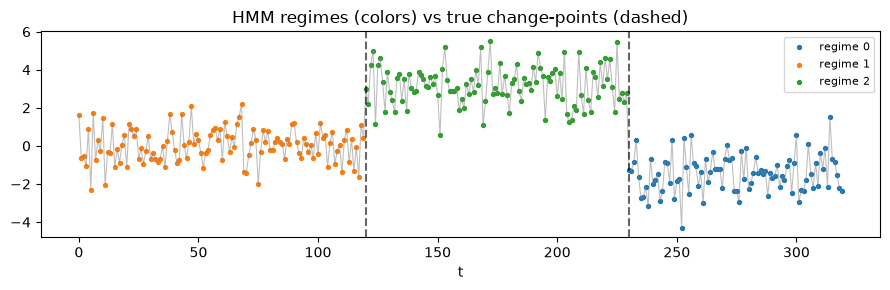

In [2]:
from mixle.stats import HiddenMarkovModelDistribution, GaussianDistribution, HiddenMarkovEstimator, GaussianEstimator
from mixle.inference.estimation import optimize

K = 3
# seed regime means at data quantiles (spread) with a sticky transition prior; fit one long sequence
seed = HiddenMarkovModelDistribution(
    [GaussianDistribution(float(q), float(np.var(y))) for q in np.quantile(y, np.linspace(0.1, 0.9, K))],
    w=[1.0 / K] * K, transitions=(0.9 * np.eye(K) + 0.1 / K).tolist())
est = HiddenMarkovEstimator([GaussianEstimator()] * K, pseudo_count=(1.0, 1.0))
hmm = optimize([list(y)], est, max_its=60, prev_estimate=seed, print_iter=100)
states = np.asarray(hmm.viterbi(list(y)))
hmm_cps = list(np.where(np.diff(states) != 0)[0] + 1)
print('HMM-decoded change-points:', hmm_cps, ' (true %s)' % true_cps)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(y, color='gray', alpha=0.5, lw=0.8)
for k in range(K):
    m = states == k
    ax.scatter(np.where(m)[0], y[m], s=8, label='regime %d' % k)
for cp in true_cps:
    ax.axvline(cp, color='k', ls='--', alpha=0.6)
ax.set_title('HMM regimes (colors) vs true change-points (dashed)'); ax.legend(fontsize=8); ax.set_xlabel('t')
plt.tight_layout(); plt.show()

## 2. Direct: optimal segmentation by dynamic programming

If you don't want a state model, search directly for the segmentation that best explains the data. With a Gaussian cost per segment (negative log-likelihood of fitting one mean to a contiguous block) and a penalty $\beta$ per change-point (to avoid splitting everywhere), the optimal set of change-points is found exactly by a 1-D dynamic program - the idea behind PELT and `ruptures`. The penalty plays the role of a model-selection knob: larger $\beta$ → fewer segments.


DP-segmentation change-points: [120, 230]  (true [120, 230])


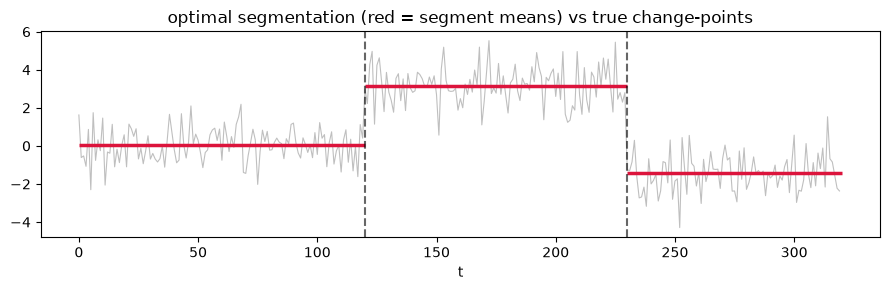

In [3]:
# segment cost = within-segment sum of squared errors (fixed-variance Gaussian NLL, up to constants);
# prefix sums make it O(1) per segment. SSE avoids the singleton-collapse of a per-segment variance MLE.
cs = np.concatenate([[0], np.cumsum(y)]); cs2 = np.concatenate([[0], np.cumsum(y ** 2)])
def seg_cost(i, j):                                   # SSE of y[i:j] around its own mean
    n = j - i; s = cs[j] - cs[i]
    return (cs2[j] - cs2[i]) - s * s / n

def segment(beta):
    best = np.full(T + 1, np.inf); best[0] = -beta; arg = [0] * (T + 1)
    for j in range(1, T + 1):
        for i in range(0, j):
            c = best[i] + seg_cost(i, j) + beta
            if c < best[j]:
                best[j] = c; arg[j] = i
    cps = []; j = T
    while j > 0:
        i = arg[j]
        if i > 0: cps.append(i)
        j = i
    return sorted(cps)

dp_cps = segment(beta=2.0 * np.var(y) * np.log(T))    # SIC-style penalty, scaled by the noise variance
print('DP-segmentation change-points:', dp_cps, ' (true %s)' % true_cps)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(y, color='gray', alpha=0.5, lw=0.8)
bounds = [0] + dp_cps + [T]
for a, b in zip(bounds[:-1], bounds[1:]):
    ax.hlines(y[a:b].mean(), a, b, color='crimson', lw=2.5)
for cp in true_cps:
    ax.axvline(cp, color='k', ls='--', alpha=0.6)
ax.set_title('optimal segmentation (red = segment means) vs true change-points'); ax.set_xlabel('t')
plt.tight_layout(); plt.show()

## Choose the penalty, do not hard-code it

The optimal-partition DP returns more change-points as the per-segment penalty $\beta$ shrinks, so $\beta$ is the model-selection knob (Lavielle 2005; Killick et al. PELT 2012). Reporting one penalty hides this. We sweep $\beta$ and watch the detected count: tiny $\beta$ over-segments (chasing noise), a huge $\beta$ collapses real regimes, and a wide plateau sits at the true count of 2 - the principled SIC choice $\beta\approx\sigma^2\log T$ lands squarely inside it.


In [4]:
sic = np.var(y) * np.log(T)                         # principled SIC-style penalty
print('SIC reference penalty sigma^2 * logT = %.1f' % sic)
print(' penalty beta   #change-points   locations')
for beta in [1, 2, 4, 8, 32, 128, 512, 900]:
    cps = segment(beta)
    loc = str(cps) if len(cps) <= 6 else '%s ...(%d total)' % (cps[:6], len(cps))
    print('   %5d        %4d            %s' % (beta, len(cps), loc))
print('true change-points: %s. Over-segments below ~4, collapses above ~512; the plateau at 2 (incl. beta=%.0f) is robust.' % (true_cps, sic))

SIC reference penalty sigma^2 * logT = 25.7
 penalty beta   #change-points   locations
       1          96            [1, 4, 5, 6, 7, 10] ...(96 total)
       2          58            [1, 5, 6, 7, 10, 11] ...(58 total)
       4           8            [120, 204, 209, 230, 252, 253] ...(8 total)
       8           2            [120, 230]


      32           2            [120, 230]
     128           2            [120, 230]


     512           2            [120, 230]
     900           0            []
true change-points: [120, 230]. Over-segments below ~4, collapses above ~512; the plateau at 2 (incl. beta=26) is robust.


## Illustration: dynamic programming beats greedy binary segmentation

We build a signal with a short raised segment in the middle (up then back down), a configuration that
trips up greedy binary segmentation. The exact dynamic program recovers both change points at the lower
total cost, while greedy, committing to one split at a time, places them worse.

In [5]:
rng = np.random.RandomState(1)
seg = np.r_[rng.normal(0, 1, 60), rng.normal(3, 1, 20), rng.normal(0, 1, 60)]   # up then down
T = len(seg); cs = np.r_[0, np.cumsum(seg)]; cs2 = np.r_[0, np.cumsum(seg ** 2)]
def cost(i, j):
    n = j - i; s = cs[j] - cs[i]; return (cs2[j] - cs2[i]) - s * s / n
beta = 2.0 * np.var(seg) * np.log(T)
def dp_segment(beta):
    F = np.full(T + 1, np.inf); F[0] = -beta; arg = [0] * (T + 1)
    for t in range(1, T + 1):
        for s in range(t):
            c = F[s] + cost(s, t) + beta
            if c < F[t]: F[t] = c; arg[t] = s
    cps = []; t = T
    while t > 0:
        s = arg[t]
        if s > 0: cps.append(s)
        t = s
    return sorted(cps), F[T]
def total_cost(cps):
    b = [0] + sorted(cps) + [T]; return sum(cost(b[k], b[k + 1]) + beta for k in range(len(b) - 1))
def greedy(beta):
    cps = []
    def best_split(i, j):
        best = (np.inf, None)
        for s in range(i + 1, j):
            c = cost(i, s) + cost(s, j)
            if c < best[0]: best = (c, s)
        return best
    segs = [(0, T)]
    while True:
        cand = None
        for (i, j) in segs:
            if j - i < 4: continue
            c, s = best_split(i, j)
            if s is not None and cost(i, j) - c > beta:           # split only if it pays the penalty
                gain = cost(i, j) - c
                if cand is None or gain > cand[0]: cand = (gain, i, j, s)
        if cand is None: break
        _, i, j, s = cand; segs.remove((i, j)); segs += [(i, s), (s, j)]; cps.append(s)
    return sorted(cps)
dp_cps, dp_cost = dp_segment(beta); g_cps = greedy(beta)
print('true change-points     : [60, 80]')
print('dynamic program        : %s   total cost = %.1f' % (dp_cps, total_cost(dp_cps)))
print('greedy binary segmentation: %s   total cost = %.1f' % (g_cps, total_cost(g_cps)))
print('the exact DP achieves the lower total cost; greedy commits early and can place splits worse.')

true change-points     : [60, 80]
dynamic program        : [60, 80]   total cost = 173.8
greedy binary segmentation: [55, 60, 80]   total cost = 191.2
the exact DP achieves the lower total cost; greedy commits early and can place splits worse.


## References

- Page, E. S. (1954). Continuous inspection schemes (https://doi.org/10.2307/2333009). Biometrika 41(1/2), 100-115. - CUSUM.
- Killick, R., Fearnhead, P. & Eckley, I. A. (2012). Optimal detection of changepoints with a linear computational cost (PELT) (https://doi.org/10.1080/01621459.2012.737745). JASA 107(500), 1590-1598.
- Adams, R. P. & MacKay, D. J. C. (2007). Bayesian online changepoint detection (https://arxiv.org/abs/0710.3742). arXiv:0710.3742.
- Truong, C., Oudre, L. & Vayatis, N. (2020). Selective review of offline change point detection methods (https://doi.org/10.1016/j.sigpro.2019.107299). Signal Processing 167.
- Fearnhead, P. (2006). Exact and efficient Bayesian inference for multiple changepoint problems (https://doi.org/10.1007/s11222-006-8450-8). Statist. Comput. 16, 203-213.


## Exercises and extensions

1. PELT and penalty selection. Implement the PELT pruning (Killick et al.) to make the dynamic program linear-time, and study penalty selection (BIC/MBIC, the elbow); plot detected change-point count vs penalty and recover the true count on simulated data.
2. Online detection and detection delay. Implement CUSUM (Page) and Bayesian online change-point detection (Adams & MacKay), and compare their detection delay and false-alarm rate to the offline methods, which see the whole series. Plot the run-length posterior.
3. Beyond mean shifts. Extend the cost/likelihood to detect changes in variance and in distribution (not just mean); show the mean-based detector misses a pure variance change and fix it (Truong et al. cost functions).
4. Stickiness vs penalty. Relate the HMM self-transition probability to the segmentation penalty: sweep both and show they trade off the same way (over- vs under-segmentation), connecting the model-based and direct approaches.
